<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Force002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Lattice parameters
grid_size = 2048
e_folds = 10000
beta_link = 1/8  # Emergent coupling strength


In [2]:
def generate_spinor_loop(grid_size):
    x = np.linspace(0, 4*np.pi, grid_size)
    y = np.linspace(0, 4*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    return np.sin(X) * np.sin(2*Y)


In [3]:
def generate_vector_field(grid_size):
    return np.tile(np.linspace(-1, 1, grid_size), (grid_size,1))


In [4]:
def emergent_coupling(spinor, vector, beta=1/8):
    # Gradients
    grad_spinor_x, grad_spinor_y = np.gradient(spinor)
    grad_vector_x, grad_vector_y = np.gradient(vector)

    # Phase difference
    theta_spinor = np.arctan2(grad_spinor_y, grad_spinor_x)
    theta_vector = np.arctan2(grad_vector_y, grad_vector_x)
    phase_diff = theta_spinor - theta_vector

    # Emergent vector mode A: 2D curl approximation
    A_x = np.gradient(grad_spinor_y)[0] - np.gradient(grad_spinor_x)[1]
    divergence_A = np.gradient(A_x)[0] + np.gradient(A_x)[1]

    # Coupling term
    coupling = -beta * np.sin(phase_diff) * divergence_A
    return spinor + coupling


In [5]:
def evolve_field(field, steps, decay=0.9999):
    evolved = field.copy()
    for _ in range(steps):
        evolved *= decay
        evolved += np.random.normal(0, 0.001, field.shape)
    return evolved


In [6]:
def memory_fidelity(original, evolved):
    return np.corrcoef(original.flatten(), evolved.flatten())[0,1]


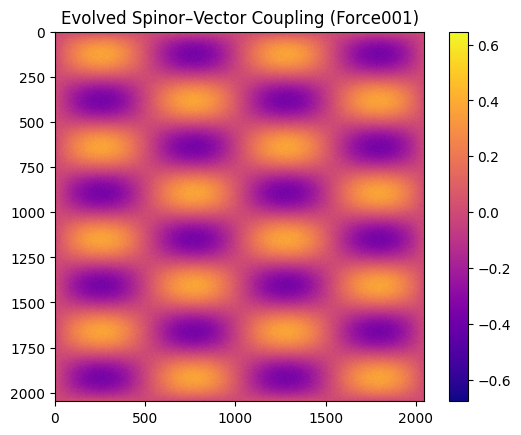

Memory fidelity after 10000 e-folds: 0.9416


In [7]:
spinor = generate_spinor_loop(grid_size)
vector = generate_vector_field(grid_size)
coupled = emergent_coupling(spinor, vector, beta_link)

evolved = evolve_field(coupled, e_folds)
fidelity = memory_fidelity(coupled, evolved)

plt.imshow(evolved, cmap='plasma')
plt.title("Evolved Spinor–Vector Coupling (Force001)")
plt.colorbar()
plt.show()

print(f"Memory fidelity after {e_folds} e-folds: {fidelity:.4f}")
